
# ===========================================
# qPCR Sample Analysis Pipeline
# Phase I - Import and Validation
# Author: Gabi Rivera
# Start Date: 25Jun2026
# ===========================================

#### Imported Libraries

In [26]:
import pandas as pd
import numpy as np

from pathlib import Path
!pip install klib
import klib

#### Handle Warnings

## Load QuantStudio 5 Dataset

### GitHub Repository

In [3]:
# Clone the GitHub Repository
!git clone https://github.com/GabiRivera0011/resiDNA_workflows.git

Cloning into 'resiDNA_workflows'...
remote: Enumerating objects: 42, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 42 (delta 14), reused 16 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (42/42), 229.11 KiB | 5.21 MiB/s, done.
Resolving deltas: 100% (14/14), done.


In [4]:
# Set the project path
project_path = Path("/content/resiDNA_workflows")
data_path = project_path / "Data"
notebook_path = project_path / "Notebooks"

print(project_path)

/content/resiDNA_workflows


In [5]:
# Verify the Data exist
list(data_path.iterdir())

[PosixPath('/content/resiDNA_workflows/Data/experiment_001.xlsx'),
 PosixPath('/content/resiDNA_workflows/Data/.gitkeep')]

In [6]:
# Load the excel workbook
file = data_path / "experiment_001.xlsx"
xls = pd.ExcelFile(file)
xls.sheet_names

['Sample Setup',
 'Results',
 'Amplification Data',
 'STD Curve',
 'NC',
 'PC',
 'S1_HIC']

### Dataset

In [13]:
# Read the desired worksheet or tab
df = pd.read_excel(
    file,
    sheet_name="Results",
    header=22
)

### MetaData

In [19]:
# Capture Metadata
metadata_df = pd.read_excel(
    file,
    sheet_name="Results",
    header=None,
    nrows=19
)

# Keep only the first two columns (Field and Value)
metadata_table = metadata_df.iloc[:, :2].copy()

# Rename columns
metadata_table.columns = ["Field", "Value"]

# Remove completely empty rows
metadata_table = metadata_table.dropna(how="all")

# Display the table
metadata_table

,Field,Value
0,Experiment Details:,NaN
1,Block Type:,0.1 mL
2,Chemistry:,TAQMAN
3,Date Created:,17 Jul 2026 11:00:56 GMT-0700
4,Barcode:,NaN
5,Comments:,Update protein concentration\nCorrect dilution...
6,Experiment Name:,2026-07-17_MD_R3_GR
7,Experiment Run End Time:,17 Jul 2026 16:14:21 GMT-0700
8,Experiment Type:,Standard Curve
9,Instrument Name:,272513207


### Regression Line Info

In [22]:
# Regression Line
regression_df = pd.read_excel(
    file,
    sheet_name="Results",
    header=None,
    skiprows=18,
    nrows=1,
    usecols="C:G"
)

regression_df

# Convert to a tidy DataFrame
regression_stats = []

for item in regression_df.iloc[0]:
    if pd.notna(item):
        key, value = str(item).split(":", 1)
        regression_stats.append({
            "Metric": key.strip(),
            "Value": value.strip()
        })

regression_table = pd.DataFrame(regression_stats)

regression_table.style.hide(axis="index").set_caption("Standard Curve Regression Statistics")

Metric,Value
R2,0.9998
Slope,-3.3008
y-Intercept,21.3153
Efficiency,100.89
Std error,0.0116


### Exploratory Data Analysis

In [14]:
# Dataset Table
df.head()

,Well,Well Position,Task,Sample Name,Target Name,Ct,Ct Mean,Ct CV%,Ct SD,Quantity,...,Back Calculation % difference,Back Calculation % difference Mean,Fit,Amplification Efficiency,Amplification Status,AMPNC,NOAMP,EXPFAIL,Protein Concentration,CQCONF
0,A1,1,NTC,NTC,CHO,Undetermined,NaN,NaN,NaN,NaN,...,NaN,NaN,Linear,100.89,No Amp,N,N,N,NaN,N
1,A2,2,NTC,NTC,CHO,Undetermined,NaN,NaN,NaN,NaN,...,NaN,NaN,Linear,100.89,No Amp,N,N,N,NaN,N
2,A3,3,NTC,NTC,CHO,Undetermined,NaN,NaN,NaN,NaN,...,NaN,NaN,Linear,100.89,No Amp,N,N,N,NaN,N
3,A4,4,UNKNOWN,S1 D1,CHO,32.3647,32.5183,0.81,0.2622,0.0004,...,NaN,NaN,Linear,100.89,Amplification,N,N,N,1.825,N
4,A5,5,UNKNOWN,S1 D1,CHO,32.3692,32.5183,0.81,0.2622,0.0004,...,NaN,NaN,Linear,100.89,Amplification,N,N,N,1.825,N


In [23]:
# Dataset General Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 45 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Well                                 96 non-null     object 
 1   Well Position                        96 non-null     int64  
 2   Task                                 69 non-null     object 
 3   Sample Name                          69 non-null     object 
 4   Target Name                          69 non-null     object 
 5   Ct                                   69 non-null     object 
 6   Ct Mean                              55 non-null     float64
 7   Ct CV%                               54 non-null     float64
 8   Ct SD                                54 non-null     float64
 9   Quantity                             55 non-null     float64
 10  Quantity Mean                        37 non-null     float64
 11  Quantity SD                       

GridSpec(6, 6)

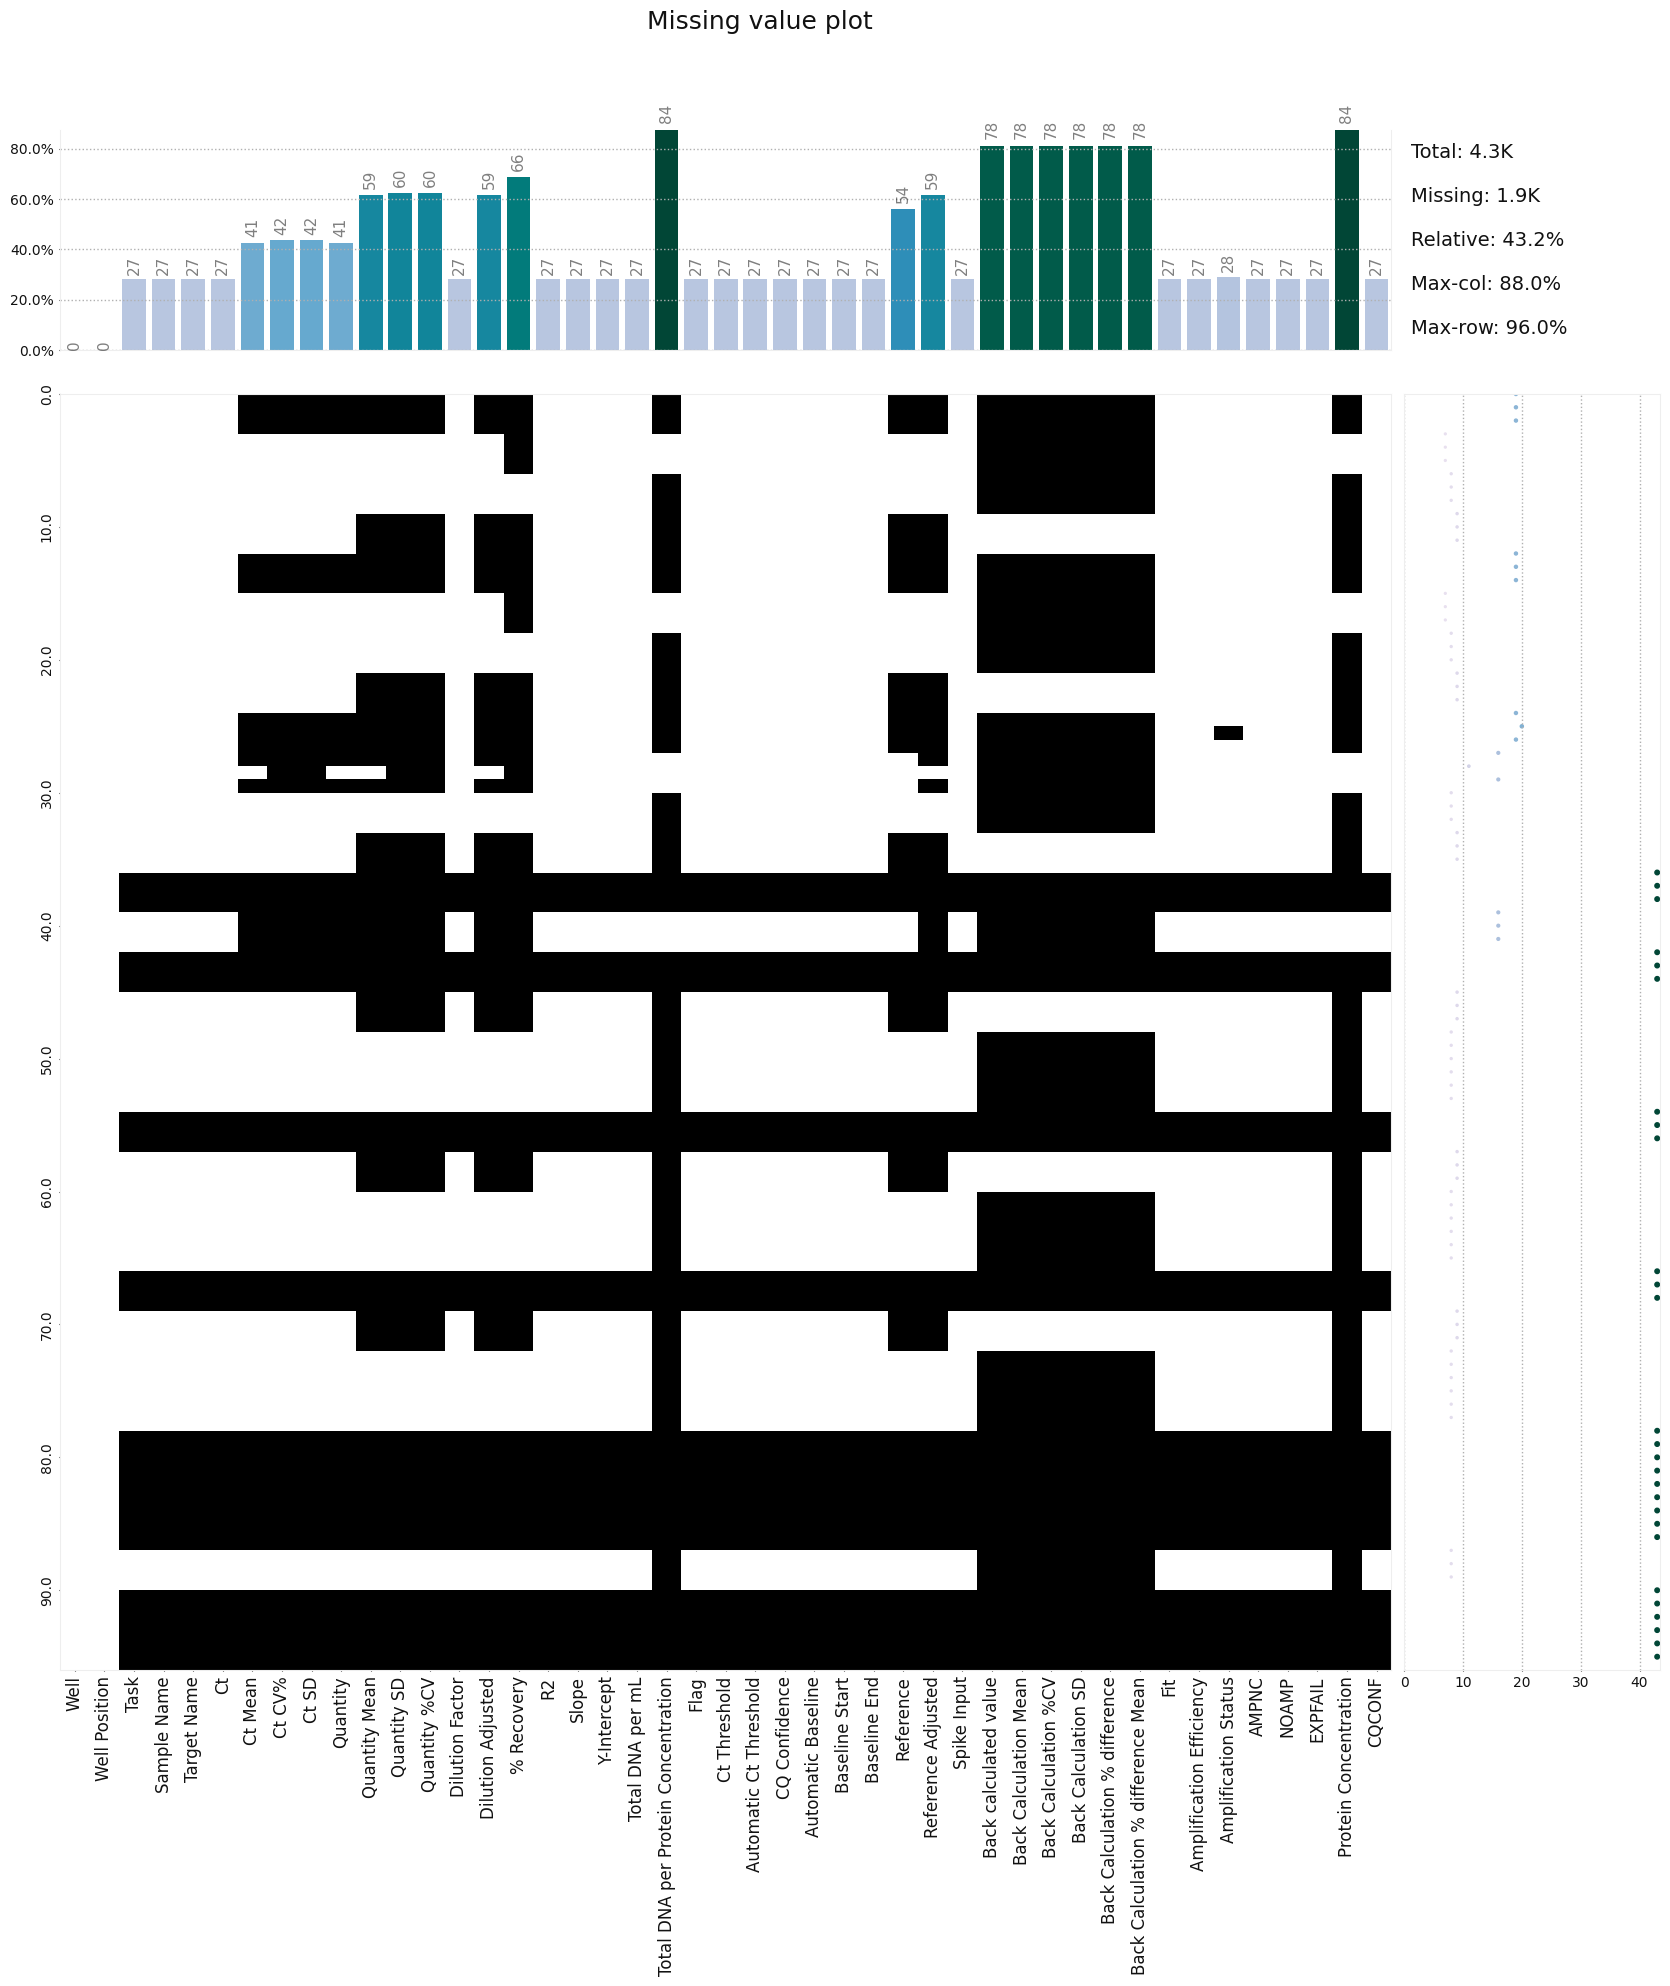

In [27]:
# Missing Value
klib.missingval_plot(df)

In [ ]:
klib.describe(df)

In [11]:


df.describe(include="all")

# Missing Value
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 45 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   A1            95 non-null     object 
 1   1             95 non-null     int64  
 2   NTC           68 non-null     object 
 3   NTC.1         68 non-null     object 
 4   CHO           68 non-null     object 
 5   Undetermined  68 non-null     object 
 6   Unnamed: 6    55 non-null     float64
 7   Unnamed: 7    54 non-null     float64
 8   Unnamed: 8    54 non-null     float64
 9   Unnamed: 9    55 non-null     float64
 10  Unnamed: 10   37 non-null     float64
 11  Unnamed: 11   36 non-null     float64
 12  Unnamed: 12   36 non-null     float64
 13  1.1           68 non-null     float64
 14  Unnamed: 14   37 non-null     float64
 15  Unnamed: 15   30 non-null     float64
 16  0.9998        68 non-null     float64
 17  -3.3008       68 non-null     float64
 18  21.3153       68 non-null     fl

,0
A1,0
1,0
NTC,27
NTC.1,27
CHO,27
Undetermined,27
Unnamed: 6,40
Unnamed: 7,41
Unnamed: 8,41
Unnamed: 9,40


## QuantStudio Results Parser

## Data Classification Engine

## System Suitability Engine

## Sample Result Processing

## Create Prototype Graphs

##